# An Exploratory Data Analysis on Students' Employability

Employability is an important factor whether a student is ready to enter the workforce. Although a student's academic performance is a well-sought measure, employability is often described by a multitude of factors other than grades. More specifically, soft skills factors such as general appearance, manner of speaking, physical condition, mental alertness, self-confidence, ability to present ideas, and communication skills may reflect a student's employability.

The dataset is acquired from [kaggle](https://www.kaggle.com/datasets/anashamoutni/students-employability-dataset) (Hamoutni, 2022). The data consists of 2,892 results from a mock interview of different universities in the Philippines. 

This analysis will seek through a multitude of soft skill factors, and student academic performance in determining one's employability. 

Specifically, this analysis seeks to answer the following main questions:
<ol style="list-style-type: lower-alpha;">
  <li>Which individual factor is most strongly associated with students being classified as Employable?</li>
  <li>Which factors demonstrate the strongest associations with Employability?</li>
  <li>Is Student Performance Rating significantly associated with Employability?</li>
  <li>Do soft skill factors exhibit multicollinearity, and does combining them (via PCA or composite scoring) improve prediction?</li>
  <li>Do combinations of factors reveal effects on employability that aren't visible when looking at each factor individually?</li>
</ol>

## I. Data Cleaning and Familiarization
Prior to the analysis itself, we must familiarize ourselves to what we are dealing with. Most often than not, there will be some data points with missing values that is required to be handled as to not hinder with the analysis' integrity and produce accurate results. The dataset will be loaded as well as importing the necessary libraries. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch    # for legends
from statsmodels.stats.outliers_influence import variance_inflation_factor    # for VIF
from sklearn.preprocessing import StandardScaler    # for PCA
from sklearn.decomposition import PCA

In [2]:
df = pd.read_excel("../data/Student-Employability-Datasets.xlsx")

df.head()

,Name of Student,GENERAL APPEARANCE,MANNER OF SPEAKING,PHYSICAL CONDITION,MENTAL ALERTNESS,SELF-CONFIDENCE,ABILITY TO PRESENT IDEAS,COMMUNICATION SKILLS,Student Performance Rating,CLASS
0,Student 1,4,5,4,5,5,5,5,5,Employable
1,Student 2,4,4,4,4,4,4,3,5,Employable
2,Student 3,4,3,3,3,3,3,2,5,LessEmployable
3,Student 4,3,3,3,2,3,3,3,5,LessEmployable
4,Student 5,4,4,3,3,4,4,3,5,Employable


The dataframe columns will be converted into snake case for readibility and consistency.

In [3]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2982 entries, 0 to 2981
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   name_of_student             2982 non-null   object
 1   general_appearance          2982 non-null   int64 
 2   manner_of_speaking          2982 non-null   int64 
 3   physical_condition          2982 non-null   int64 
 4   mental_alertness            2982 non-null   int64 
 5   self-confidence             2982 non-null   int64 
 6   ability_to_present_ideas    2982 non-null   int64 
 7   communication_skills        2982 non-null   int64 
 8   student_performance_rating  2982 non-null   int64 
 9   class                       2982 non-null   object
dtypes: int64(8), object(2)
memory usage: 233.1+ KB


The above shows that for all rows (n=2982) of our dataframe, none have missing or null values. It also shows the datatype stored in each column. Columns 1 through 8 are all integer datatypes, making analysis more convenient without having to resolve data type mismatches. Another thing to note is that the `class` column, or the value whether a student is employable or not, is of object data type. Hence, it must be ensured that this column must only consist of, in this case, "Employable" or "LessEmployable".

In [5]:
df["class"].describe()

count           2982
unique             2
top       Employable
freq            1729
Name: class, dtype: object

Looking at the number of unique rows, we are confident that the `class` column is limited to the two options described above.

Aside from looking for missing values, duplicate rows must also be removed. Conveniently, the dataset provides us the `name_of_student`. Evidently, the names are anonymized, however, having unique "names" ensures that two rows having the same scores and classification corresponds to two different students. Hence, looking for duplicate rows may be simply done as follows:

In [6]:
df["name_of_student"].describe()

count             2982
unique            2982
top       Student 3000
freq                 1
Name: name_of_student, dtype: object

Since all names are unique, it is implied that the dataframe contains no duplicate values that hinders data integrity.

In [7]:
df.describe()

,general_appearance,manner_of_speaking,physical_condition,mental_alertness,self-confidence,ability_to_present_ideas,communication_skills,student_performance_rating
count,2982.000000,2982.000000,2982.000000,2982.000000,2982.000000,2982.000000,2982.000000,2982.000000
mean,4.246814,3.884641,3.972166,3.962777,3.910798,3.813883,3.525486,4.610664
std,0.678501,0.757013,0.744135,0.781982,0.807602,0.739390,0.743881,0.692845
min,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000
25%,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000
50%,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000
75%,5.000000,4.000000,5.000000,5.000000,5.000000,4.000000,4.000000,5.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


Looking at the maximum and minimum values, the students' scores are bounded in a 5-point scale ranging up to 5, albeit none have scored less than 2. Therefore, having being familiarized and examined with the data, this dataset is prepared to proceed with the analyses.

## II. Univariate Analysis

### A. Distribution of Ratings

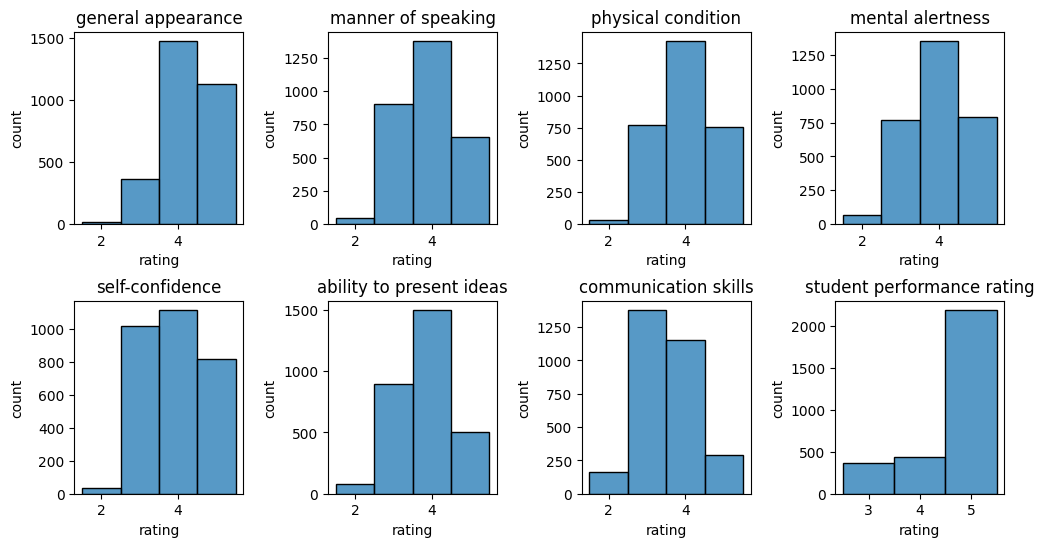

In [8]:
predictor_cols = ["general_appearance", "manner_of_speaking", "physical_condition", "mental_alertness",
                  "self-confidence", "ability_to_present_ideas", "communication_skills", "student_performance_rating"]

figure, axes = plt.subplots(2, 4, figsize=(12,6))

axes = axes.flatten()

for i, col in enumerate(predictor_cols):
    sns.histplot(df[col], ax=axes[i], discrete=True)
    axes[i].set_title(col.replace("_", " "))
    axes[i].set_ylabel("count")
    axes[i].set_xlabel("rating")

plt.subplots_adjust(hspace=0.4, wspace=0.5)
plt.show()

Most of the histograms displays relatively high ratings. Majority of the ratings ranges from 3-5, while there are a few students receiving a rating of 2.

In [9]:
df[predictor_cols].skew()

general_appearance           -0.452415
manner_of_speaking           -0.028022
physical_condition           -0.111690
mental_alertness             -0.212908
self-confidence               0.037227
ability_to_present_ideas     -0.097850
communication_skills          0.218410
student_performance_rating   -1.493381
dtype: float64

The skewness of each rating is shown above. Despite the visual representation of the data, it is found that only `student_performance_rating` scored high skewness. Moreover, `general_appearance` is edging the line between being symmetric and moderately skewed. Thus, it is beneficial for future predictive modelling and analyses to normalize this dataset to produce accurate results.

### B. Spread and Outlier Analysis

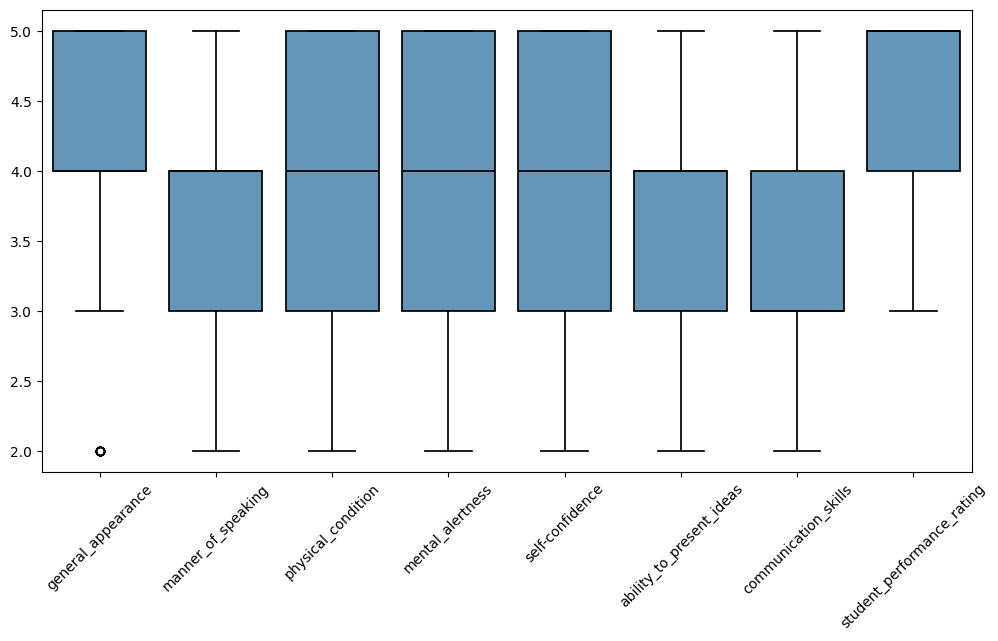

In [10]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df[predictor_cols], color="#5799c6", linewidth=1.25, linecolor="black",)
plt.xticks(rotation=45)

plt.show()

The above shows the interquartile range (IQR), minimum and maximum values, and the median of each criteria. Similar to the one displayed by the histograms, the IQR is mostly located from 3 above. By the IQR, only the column general apperance has an outlier that should be dealt with for predictive modelling. However, this exploratory data analysis does not concern handling outliers in this dataset.

### C. Percentage of Classification

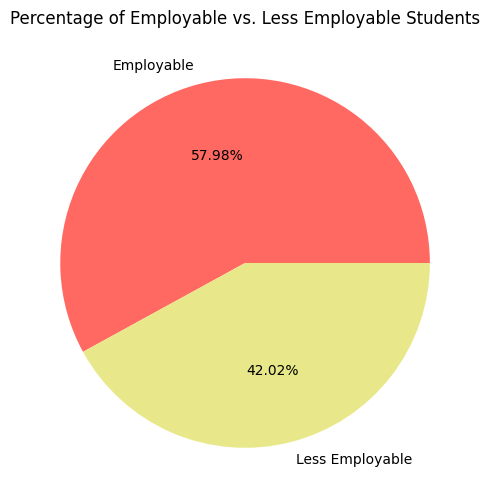

In [11]:
plt.figure(figsize=(8,6))

plt.pie(
    df["class"].value_counts(),
    autopct="%1.2f%%",
    colors=["#FF6961", "#E8E88A"],
    labels=["Employable", "Less Employable"])

plt.title("Percentage of Employable vs. Less Employable Students")
plt.show()

### ***Key Insights***

The dataset is free from any missing or duplicate rows. However, the dataset requires normalization since some factors, namely `student_performance_rating` and `general_appearance` are skewed. Additionally, `Employable` takes up 57.98% of the data, while `LessEmployable` as the rest. 

## III. Bivariate Analysis

### A. Distribution of Classification in each Rating

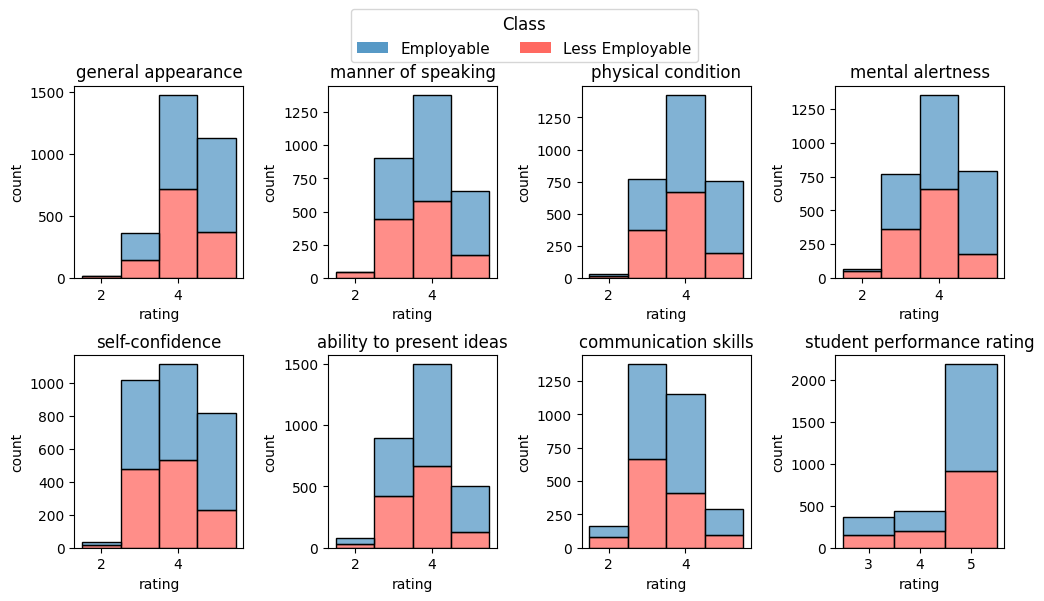

In [12]:
figure, axes = plt.subplots(2, 4, figsize=(12,6))

axes = axes.flatten()

for i, col in enumerate(predictor_cols):
    sns.histplot(
        data=df,
        x=col,
        hue="class",
        discrete=True,
        multiple="stack",
        ax=axes[i],
        palette=["#5799C6", "#FF6961"],
        legend=False
    )
    axes[i].set_title(col.replace("_", " "))
    axes[i].set_xlabel("rating")
    axes[i].set_ylabel("count")

handles = [
    Patch(facecolor="#5799C6", label="Employable"),
    Patch(facecolor="#FF6961", label="Less Employable")
]

figure.legend(
    handles=handles,
    title="Class",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    fontsize=11,
    title_fontsize=12
)

plt.subplots_adjust(hspace=0.4, wspace=0.5)
plt.show()

Majority of the bars, especially with ratings less than 5, has an almost equal number of students in each classification. Meanwhile, on rating 5, there are more students that are classified as `Employable`, with the sole exception of `student_performance_rating`, having an equal distribution. Also, the rating 4 on `communication_skills` tends to have more `Employable` students. On the other hand, students getting a rating of 2 for `manner_of_speaking` and `mental_alertness` are more likely to be classified as `LessEmployable`.

### B. Percentage of Classification in Each Rating

**1. Identifying Each Percentage**

In [13]:
for i, col in enumerate(predictor_cols):
    print(df["class"].groupby(df[col]).value_counts() / df[col].value_counts())

general_appearance  class         
2                   LessEmployable    1.000000
3                   Employable        0.592798
                    LessEmployable    0.407202
4                   Employable        0.513550
                    LessEmployable    0.486450
5                   Employable        0.670505
                    LessEmployable    0.329495
Name: count, dtype: float64
manner_of_speaking  class         
2                   LessEmployable    1.000000
3                   Employable        0.506652
                    LessEmployable    0.493348
4                   Employable        0.576197
                    LessEmployable    0.423803
5                   Employable        0.730887
                    LessEmployable    0.269113
Name: count, dtype: float64
physical_condition  class         
2                   Employable        0.531250
                    LessEmployable    0.468750
3                   Employable        0.510363
                    LessEmployable    0.

The above simply shows the percentages of `Employable` and `LessEmployable` in each bar. The purpose of this is to reliably identify which among the ratings of each factors are reasonably unbalanced, say > 60%; that is, the percentage difference between Employable and LessEmployable of a given rating is >= 20% or <= -20%. 

**2. Visualize Percentages with High Differences**

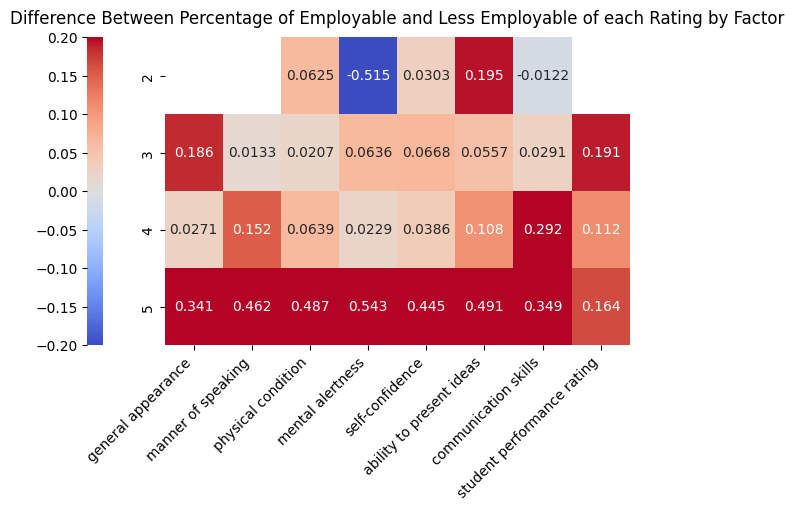

In [14]:
diff_data = {}

for i, col in enumerate(predictor_cols):
    less_employable = df[(df["class"] == "LessEmployable")].groupby(df[col]).size()
    employable = df[(df["class"] == "Employable")].groupby(df[col]).size()

    diff_data[col] = (employable - less_employable) / (less_employable + employable)

df_diff = pd.DataFrame(diff_data)

plt.figure(figsize=(8, 4))
ax = sns.heatmap(df_diff,
                 vmax=0.2, 
                 vmin=-0.2,
                 annot=True, 
                 cmap="coolwarm",
                 cbar_kws={"location": "left",},
                 center=0, 
                 fmt=".3g",)

labels = [label.get_text().replace("_", " ") for label in ax.get_xticklabels()]
ax.set_xticklabels(labels, rotation=45, ha="right")
plt.title("Difference Between Percentage of Employable and Less Employable of each Rating by Factor", pad=10)
plt.show()

*Note:* Rounding the values off into 3 decimal places is sufficient to get rid off rounding errors.

The factors `general_appearance`, `manner_of_speaking`, `physical_condition`, `mental_alertness`, `self-confidence`, `ability_to_present_ideas`, `communication_skills` has a high percentage difference between the number of `Employable` and `LessEmployable` where rating is 5. Meanwhile, there is also a high difference in `communication_skills` where rating is 4, as well as in `mental_alertness` where rating is 2 that is leaned towards the `LessEmployable` side. From the data above, we can infer a student's likelihood of being classified as `Employable` by looking at the achieved score on a specific combination of factor and rating. For instance, a student having a rating of 5 in `mental_alertness`, there is a relatively high probability of being classified as `Employable`. 

It is also noteworthy that other than `mental_alertness`, factors with high difference where rating is 5 has a relatively equal distribution or low difference where rating is 2. Since the mentioned factors have high difference percentage on high ratings, one may expect the same pattern is also true on low ratings.

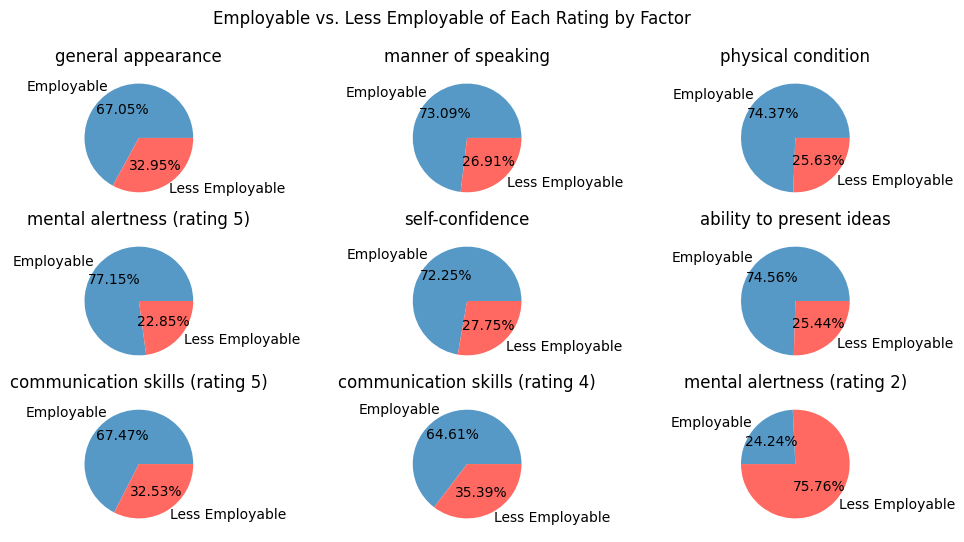

In [15]:
high_difference_cols = ["general_appearance", "manner_of_speaking", "physical_condition", "mental_alertness",
                 "self-confidence", "ability_to_present_ideas", "communication_skills"]

figure, axes = plt.subplots(3, 3, figsize=(12,6))

axes = axes.flatten()

# Plot the pie chart of Employable vs Less Employable where rating is 5
for i, col in enumerate(high_difference_cols):
    axes[i].pie(df["class"].where(df[col] == 5).value_counts(), 
                autopct='%1.2f%%',
                colors=["#5799C6", "#FF6961"],
                labels=["Employable", "Less Employable"],
                )
    axes[i].set_title(col.replace("_", " "))


# An additional pie chart for communication skills where rating is 4
axes[7].pie(df["class"].where(df["communication_skills"] == 4).value_counts(), 
            autopct='%1.2f%%',
            colors=["#5799C6", "#FF6961"],
            labels=["Employable", "Less Employable"])

# An additional pie chart for mental alertness where rating is 2
axes[8].pie(df["class"].where(df["mental_alertness"] == 2).value_counts(), 
            autopct='%1.2f%%',
            colors=["#FF6961", "#5799C6"],
            labels=["Less Employable", "Employable"],
            startangle=180)

# Modify pie chart titles with duplicate columns
axes[3].set_title("mental alertness (rating 5)")
axes[6].set_title("communication skills (rating 5)")
axes[7].set_title("communication skills (rating 4)")
axes[8].set_title("mental alertness (rating 2)")

plt.suptitle("Employable vs. Less Employable of Each Rating by Factor")
plt.show()

The factor and rating combination with high percentage differences were extracted and plot into a pie chart. Note that some of the pie charts does not specify which rating it corresponds to but by default, the rating is 5. Moreover, the rating was only specified on duplicate factor. Nevertheless, the above shows that, from highest to lowest, scoring a 5 on `mental_alertness`, `ability_to_present_ideas`, and `physical_condition` has the highest probabilities of being classified as `Employable`.

### *Key Insights*

Having a rating 5 on `mental_alertness` has a 77.15% probability of being classified as `Employable`. However, a rating of 2 in `mental_alertness` results to 75.76% probability of being classified as `LessEmployable`. This shows the importance of `mental_alertness` in students' employability.

### C. Correlation of One Factor to Another

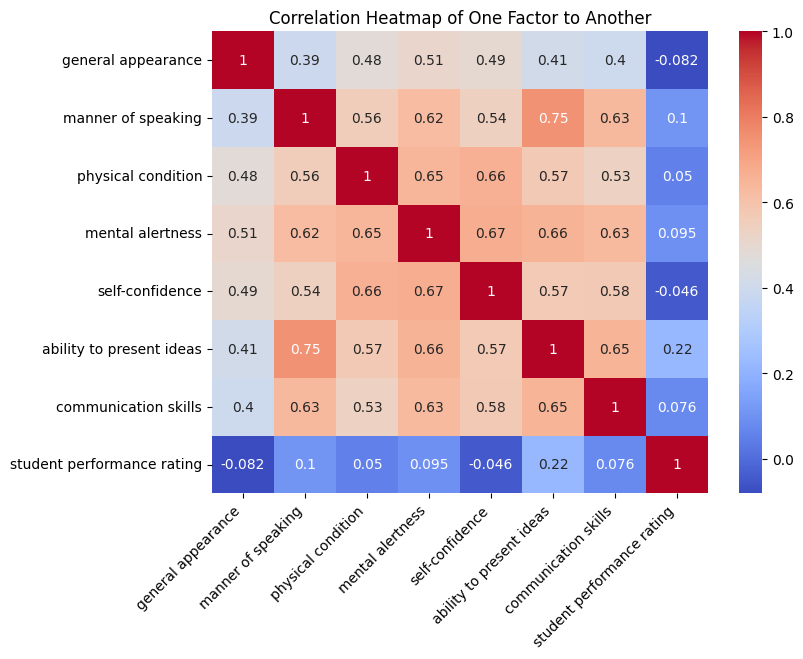

In [16]:
corr = df.corr(method="spearman", numeric_only=True) #spearman correlation

plt.figure(figsize=(8,6))
ax = sns.heatmap(corr, cmap="coolwarm", annot=True)
labels = [label.get_text().replace("_", " ") for label in ax.get_xticklabels()]
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

plt.title("Correlation Heatmap of One Factor to Another")
plt.show()

The above shows the correlations between two factors. Notably, there is a high correlation between `manner_of_speaking` and `ability_to_present_ideas`. Also, a moderate correlation can be found across all soft skills, but very weak correlation to `student_performance_rating`.

### D. Correlation of Each Factor to Classification

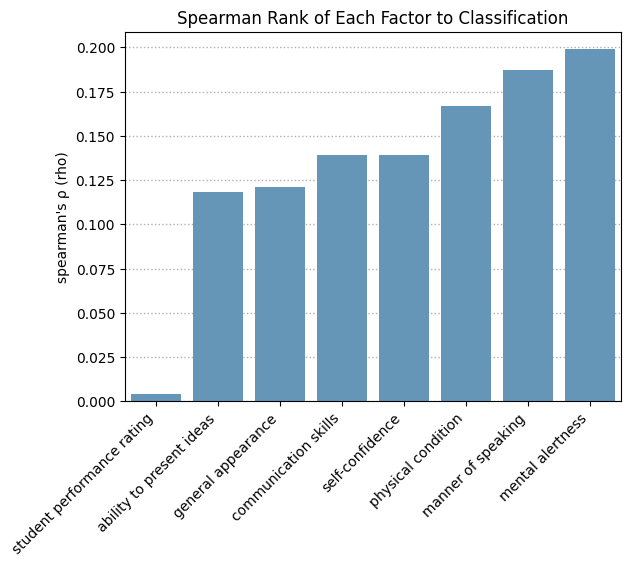

In [17]:
df["class_encoded"] = df["class"].map({"Employable": 1, "LessEmployable": 0})

spearman_corr = (df[predictor_cols]
                 .corrwith(df["class_encoded"], method="spearman")
                 .sort_values(ascending=False))

ax = sns.barplot(spearman_corr.sort_values(ascending=True), color="#5799C6", zorder=2)

ax.set_xticks(ax.get_xticks())
labels = [label.get_text().replace("_", " ") for label in ax.get_xticklabels()]
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("spearman's ρ (rho)")

plt.grid(visible=True, which="major", axis="y", linestyle=":", linewidth=1, zorder=0)
plt.title("Spearman Rank of Each Factor to Classification")
plt.show()

`mental_alertness` and `manner_of_speaking` scored the highest correlation to classification, albeit all factors are weakly correlated to `class`. Moreover, similar to how `student_performance_rating` is weakly correlated to the other factors, the same behavior applies to `class` with little to no correlation.

### *Key Insights*

Based on the correlation analyses, `student_performance_rating` does not hold any correlative significance in classifying a student's employability.

## IV. Multivariate Analysis

### A. Percentage of Classification Among the Combination of Mental Alertness and Manner of Speaking

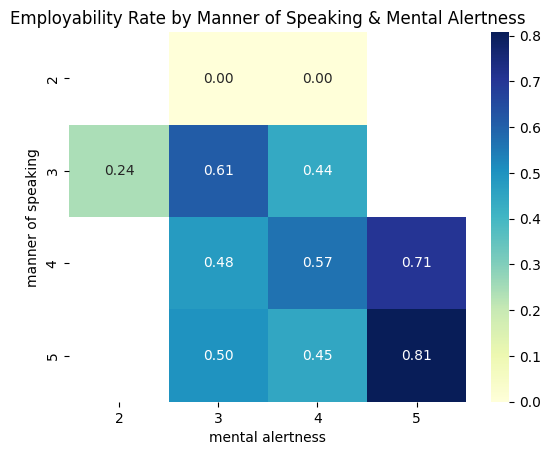

In [18]:
pivot = df.pivot_table(index="manner_of_speaking",
                       columns="mental_alertness",
                       values="class_encoded")

sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Employability Rate by Manner of Speaking & Mental Alertness")
plt.xlabel("mental alertness")
plt.ylabel("manner of speaking")
plt.show()

The heatmap shows the percentages of Employable students across the combination of `mental_alertness` and `manner_of_speaking`, denoted in the form of (X,Y). 81% of students scoring (5,5) are classified as `Employable`. The second highest percentage comes from scoring (5,4). High percentages can be observed across the diagonal. Interestingly, scoring (3,3) has a higher chance of being classified as `Employable` than (4,4). Further, there is a sharp decrease in percentages of Employable students from a score of 5 in `mental_alertness` to 4. Moreover, scoring (3,2) and (4,2) does not entail to `Employable`.

### ***Key Insights***
Scoring (5,5) in `mental_alertness` and `manner_of_speaking` has an 81% employability rate, whereas (5,4) drops it to 45%. However, (4,5) gives 71% probability of being `Employable`.

### B. Variance Influence Factor (VIF) of Factors

In the *Correlation Heatmap of One Factor to Another*, high correlation were found between each factors, generally above 0.50 except for `general_appearance` and `student_performance_rating`. Hence, it would be sensible to check the factors for multicollinearity using VIF. To differentiate, correlation refers to how two variables move together, while multicollinearity states if a given predictor is redundant or can be expressed by the others. Having multicollinearity can have serious consequences when using regression. Although multicollinearity may not reduce the model's ability to predict, it may, however, make it harder to understand the relative importance of the predictor variables (Franke, 2010).

In [19]:
X = df[predictor_cols]

# Code adapted from https://www.geeksforgeeks.org/python/detecting-multicollinearity-with-vif-python/
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

vif_data

,feature,VIF
0,general_appearance,47.245065
1,manner_of_speaking,66.243133
2,physical_condition,63.191697
3,mental_alertness,71.316184
4,self-confidence,59.551224
5,ability_to_present_ideas,79.103813
6,communication_skills,49.537228
7,student_performance_rating,26.198988


VIF values above 5 could imply collinearity, while above 10 is severely correlated with another feature, however, this treshold may vary and collinearity issues may still arise depending on the size of data (Franke, 2010). Nevertheless, the table above shows that the VIF values of each factor ranges from 26.20 to 79.10, making the factors highly correlated with one another.

It could be implied that the first 7 factors with the highest VIF values are rated based on judgment and impression of the interviewer. Hence, it may be possible that by the "Halo effect," scoring high in one factor would also lead to high scores to others, and vice versa.

### *Key Insights*

Further statistical analyses must first address this VIF issue, whether by combining factors or dropping less important factors to reduce the VIF values to an acceptable range.

### C. Factor Combination Analysis
As discussed above, irrelevant or redundant factors can be dropped or combined with other factors for better accuracy. Hence, the analysis in this section will make use of Principal Component Analysis (PCA) and composite score aggregation by computing the mean of selected factors. By doing so, the seven highly correlated factors will be simplified into non-redundant predictors to be used for future analyses.

Moreover, note that `student_performance_rating` has little to no correlation to `class`. Hence, for the purpose of this analysis, `student_performance_rating` will be removed and we'll be focusing on the seven soft skills, namely `general_appearance`, `manner_of_speaking`, `physical_condition`, `mental_alertness`, `self-confidence`, `ability_to_present_ideas`, and `communication_skills`.

In [20]:
soft_skill_cols = predictor_cols[:7]
print(soft_skill_cols)

['general_appearance', 'manner_of_speaking', 'physical_condition', 'mental_alertness', 'self-confidence', 'ability_to_present_ideas', 'communication_skills']


**1. Principal Component Analysis**

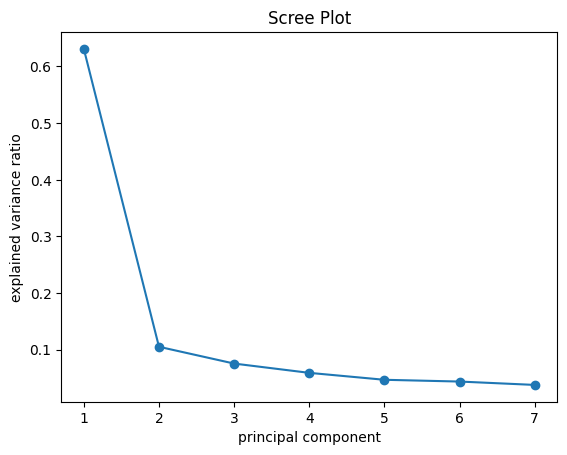

In [21]:
# Perform pca 
# Code adapted from: https://www.geeksforgeeks.org/data-analysis/principal-component-analysis-with-python/
X = df[soft_skill_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Plot the explained variance ratio
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, marker='o')

plt.xlabel("principal component")
plt.ylabel("explained variance ratio")

plt.title("Scree Plot")
plt.show()

The above shows that the first principal component (PC1) holds the majority of the explained variance ratio and significantly drops as the graphs go to the second. This means that the PCA would only consist of one component as will be indicated below:

In [22]:
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_scaled)

df["pc1"] = X_pca[:, 0] # Assigns an array of any number of dimensions to a single column

loadings = pd.DataFrame(pca.components_.T, columns=["PC1"], index=X.columns)
print(loadings)

                               PC1
general_appearance        0.299978
manner_of_speaking        0.386172
physical_condition        0.377840
mental_alertness          0.407157
self-confidence           0.390152
ability_to_present_ideas  0.398182
communication_skills      0.376267


The above shows the PCA loadings or the feature weights of PC1. Feature weights describes how much each raw factor contributes to building PC1. Evidently, every soft skill feature has a positive weight, ranging roughly from 0.30 to 0.41. No single feature heavily outweighs the others, hence PC1 represents an evenly weighted aggregate in combining all soft skills. Further, this also implies that the evaluator/s does not assess each trait individually and in isolation. Instead, students scoring high in `mental_alertness` almost always scores high in `ability_to_present_ideas` and `self-confidence` as also indicated in their correlation. Also, `general_appearance`, while still positive, has the lowest weight among the features, suggesting that while appearance moves with other traits, core cognitive and verbal communication skills are the main drivers in candidate perception.

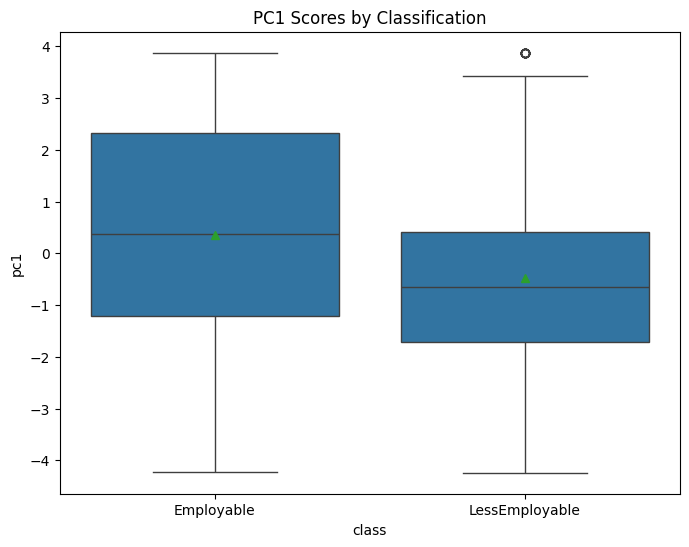

In [23]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="class", y="pc1", showmeans=True)

plt.title("PC1 Scores by Classification")
plt.show()

The above shows the PC1 scores Employable and Less Employable students. Students belonging in `Employable` class has higher quartile values, mean, and median values. However, the maximum and minimum values seems similar.

In [24]:
df[["pc1", "class_encoded"]].corr(method="spearman")

,pc1,class_encoded
pc1,1.000000,0.181285
class_encoded,0.181285,1.000000


The correlation between PC1 and `class_encoded` is 0.18. For comparison, the feature with the highest correlation to `class` is `mental_alertness` with a score of 0.20. Hence, it may be more reliable to use `mental_alertness` alone in predicting `class`, albeit both have weak correlations.

**2. Composite Score Aggregation**

Aside from PCA, taking the mean scores of the soft skills is also a viable option in combining features. By taking the mean, each feature will have an equal weight, as opposed to PCA loadings. Moreover, taking the mean retains the original 1-5 scale.

In [25]:
df["soft_skill_score"] = df[soft_skill_cols].mean(axis=1)

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="class", y="soft_skill_score", showmeans=True)

plt.grid(visible=True)
plt.show()

Similar to the PCA, the quartile values, mean, and median in `Employable` is higher than `LessEmployable`.

In [ ]:
df[["soft_skill_score", "class_encoded"]].corr(method="spearman")

Impression scores and `class` are also weakly correlated (ρ = 0.18), similar to PC1.

### ***Key Insights***

Combining factors by PCA and composite feature aggregation solves VIF issues, but correlation values scored worse than correlation values of some individual factors.

## V. Conclusion

The analysis examined 2,982 mock interview records to identify factors associated with student employability. The analysis also examined whether these factors could be meaningfully combined for future predictive work.

(a) Among all factor-rating combinations, `mental_alertness` showed the strongest association with the `Employable` class. 77.15% of students with a rating of 5 were classified as `Employable`, while a rating of 2 in the said factor has a 75.76% probability of being `LessEmployable`.

(b) `mental_alertness` and `manner_of_speaking` scored the highest Spearman correlations with `class`, though all seven soft skill factors were weakly correlated with employability having ρ < 0.20. This suggests that while soft skills matter, no single factor is strongly predictive on its own. It is likely that employability comes from a combination of factors or variables outside the dataset.

(c) `student_performance_rating` showed little to no correlation with both the soft skills and `class,`, indicating that academic performance does not meaningfully explain employability outcomes. Popular belief often associates academic performance with overall career success; however, the finding contradicts this assumption.

(d) The seven skill factors demonstrated severe multicollinearity, with VIF values ranging from 26.20 to 79.10. Combining these factors via PCA and via composite score aggregation both resolved the multicollinearity issue, but neither outperformed `mental_alertness` in correlation with employability.

(e) The pivot analysis between `mental_alertness` and `manner_of_speaking` revealed a non-linear pattern not visible in univariate and bivariate analysis alone. To specify, students scoring (3,3) have a higher employability rate than those scoring (4,4). Moreover, there is a sharp drop between (5,5) and (5,4), but not (4,5). This indicates that specific combinations of ratings better explain employability, rather than any single high score.

## References

- Franke, G. R. (2010). Multicollinearity. *Wiley international encyclopedia of marketing*. https://doi.org/10.1002/9781444316568.wiem02066
- Hamoutni A. (2022). Students Employability Dataset, Version 1. https://www.kaggle.com/datasets/anashamoutni/students-employability-dataset/version/1